In [1]:
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import optimizers

In [4]:
memory_type = torch.device('cuda')
dtype = torch.float32
num_modes = 1
study = 'TE'

# device 1

In [16]:
# # parameters
# lambd = 1.55
# 
# # wave number and normalized spacing
# k_0 = 2 * np.pi / lambd
# 
# # device 1
# 
# # spacing
# dx = 0.05 * k_0
# dy = 0.05 * k_0
# 
# # simulation lengths
# core_length_x = 1 * k_0 # W
# core_length_y = 1 * k_0 # H
# 
# substrate_length_x = 3.0 * k_0 # Xs
# substrate_length_y = 3.0 * k_0 # Ys
# 
# # refractive indices
# n_core = 3
# n_substrate = 1

In [35]:
# parameters
lambd = 1.55

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 2

# spacing
dx = lambd / 20 * k_0
dy = lambd / 20 * k_0

# simulation lengths
core_length_x = 2 * lambd * k_0 # W
core_length_y = 2 * lambd *  k_0 # H

substrate_length_x = 2 * lambd * k_0 # Xs
substrate_length_y = 2 * lambd * k_0 # Ys

# refractive indices
n_core = 1.7
n_substrate = 1.2

In [36]:
weights = [1, 1, 1, 1, 1, 1e-1]
m = 1e1

In [37]:
lengths_x = [substrate_length_x, core_length_x, substrate_length_x]
lengths_y = [substrate_length_y, core_length_y, substrate_length_y]
RIs = [n_substrate, n_core]

In [38]:
reference_device = devices.BuriedChannelWaveguide(RIs, lambd, lengths_x, lengths_y, study, 'E')

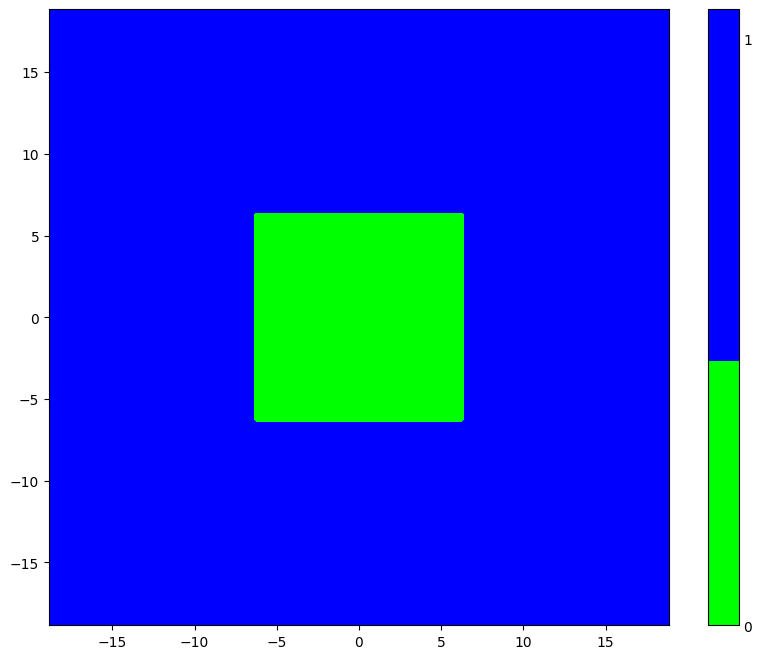

In [39]:
reference_device.plot(dx, dy)

In [52]:
torch.manual_seed(42)
base_model = models.discontinuity_capturing_network(2, 64, num_modes, 3, ['DRBF', 'DRBF'])
optimizer = optimizers.SOAP(
    base_model.parameters(),
    lr=1e-2,
    betas=(0.9, 0.99),
    weight_decay=0,
    precondition_frequency=1
)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[9000, 10000], gamma=1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 8641


In [53]:
# mesh = samplers.uniform_grid_2d(reference_device, dx/2, dy/2, dtype, 'cpu')
# features = reference_device.make_features(mesh)
# 
# plt.scatter(mesh[:, 0].cpu().detach(), mesh[:, 1].cpu().detach(), s=1, c=features, cmap='jet');

In [54]:
device = devices.BuriedChannelWaveguideWithPINNs(RIs, lambd, lengths_x, lengths_y, study, 'E', base_model, 1, True)

In [55]:
reference_device_fd = devices.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy)

In [56]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=1.5, n_upper=None)

  0%|          | 0/11001 [00:00<?, ?it/s]

num samples 14641


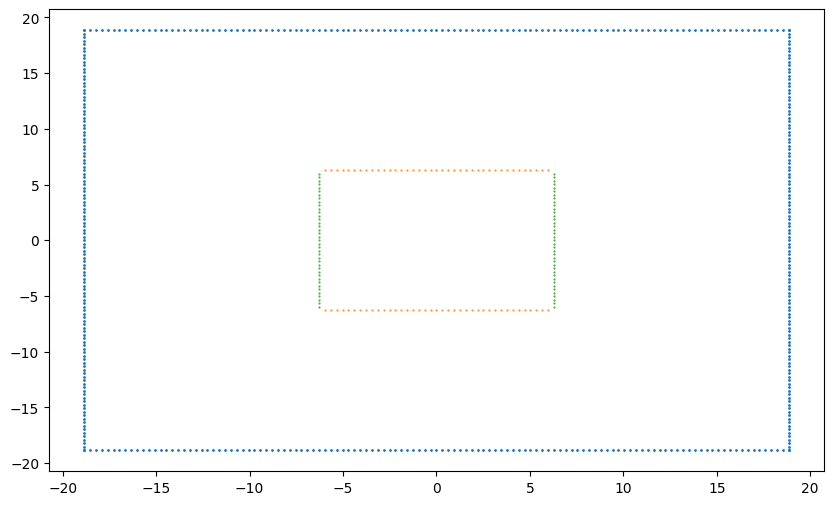

loss1 is  0.01070, loss2 is  0.54666, loss3 is  1.28087, loss4 is  0.00000, loss5 is  0.03574, loss6 is  0.01871, total loss  1.89268, RI value  1.26869:   0%|          | 0/11001 [00:00<?, ?it/s]

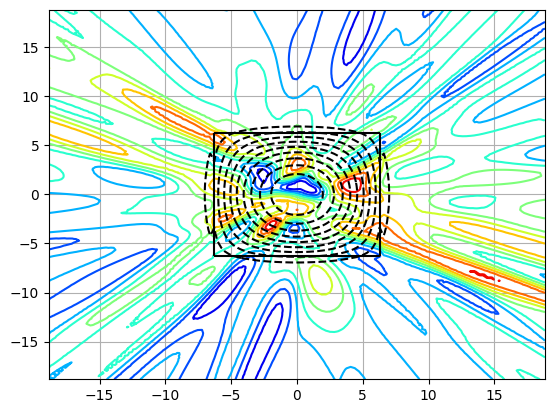

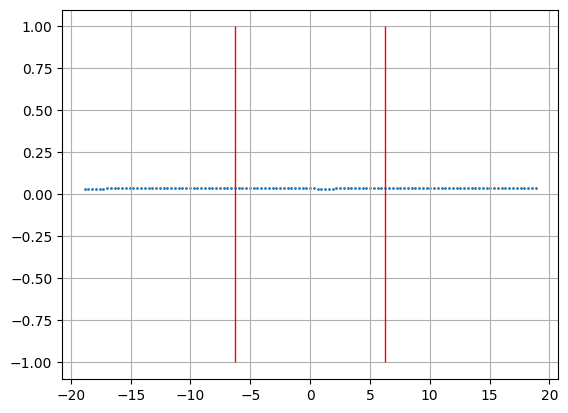

loss1 is  0.00712, loss2 is  0.00451, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00060, loss6 is  0.02531, total loss  0.03754, RI value  1.66992:   5%|▍         | 498/11001 [00:17<05:38, 31.05it/s]

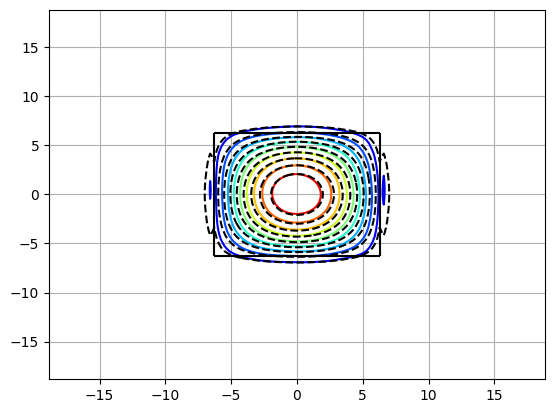

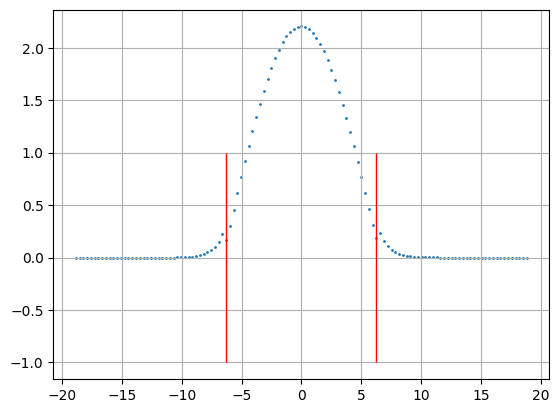

loss1 is  0.00460, loss2 is  0.00363, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00064, loss6 is  0.02934, total loss  0.03822, RI value  1.66983:   9%|▉         | 998/11001 [00:34<05:24, 30.78it/s]

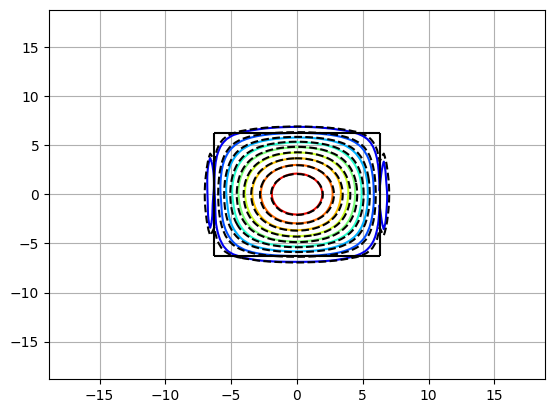

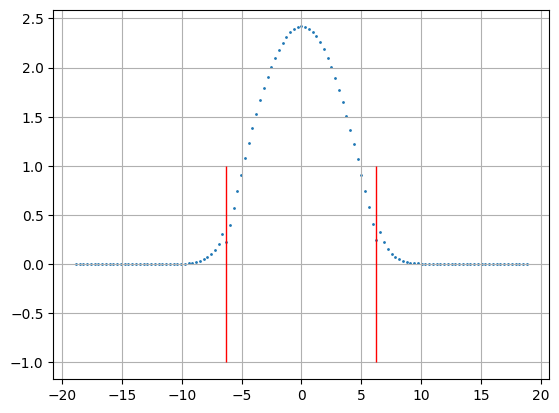

loss1 is  0.00349, loss2 is  0.00325, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00070, loss6 is  0.03361, total loss  0.04105, RI value  1.66974:  14%|█▎        | 1498/11001 [00:50<05:04, 31.23it/s]

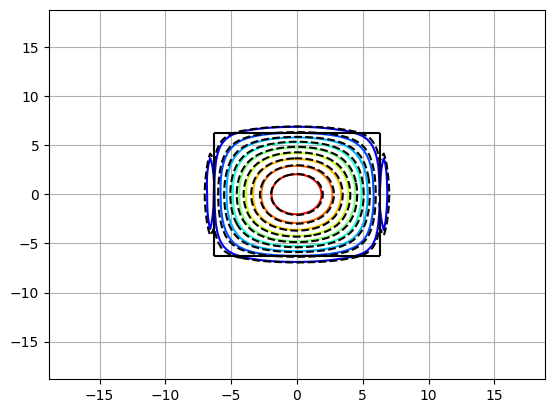

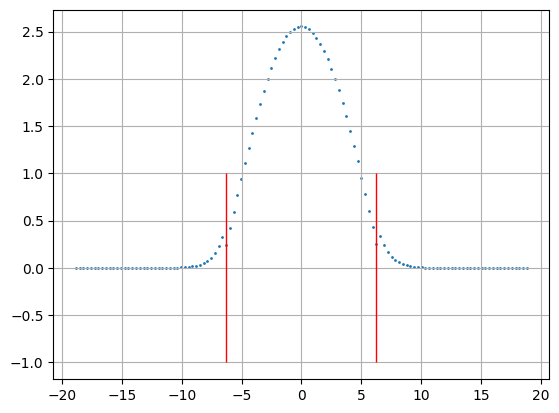

loss1 is  0.00294, loss2 is  0.00288, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00064, loss6 is  0.03179, total loss  0.03825, RI value  1.66980:  18%|█▊        | 1999/11001 [01:08<05:33, 26.97it/s]

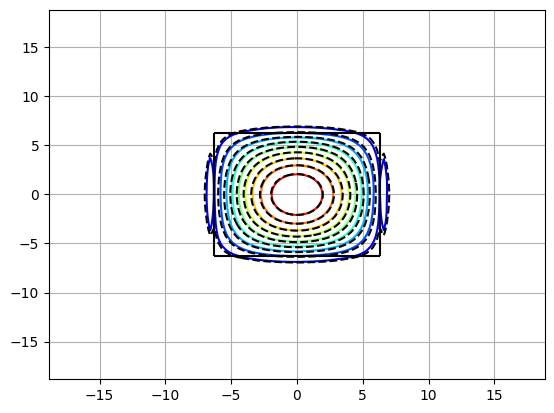

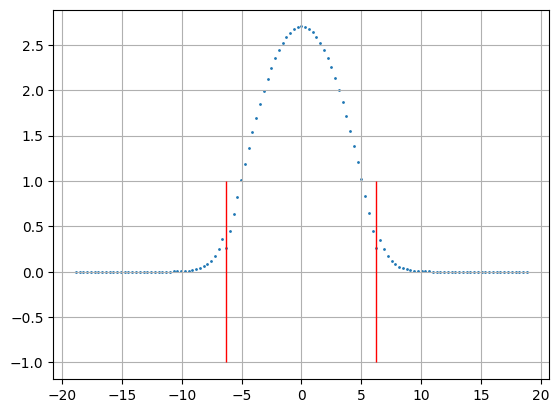

loss1 is  0.00291, loss2 is  0.00283, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00085, loss6 is  0.03310, total loss  0.03968, RI value  1.66980:  23%|██▎       | 2500/11001 [01:26<05:45, 24.61it/s]

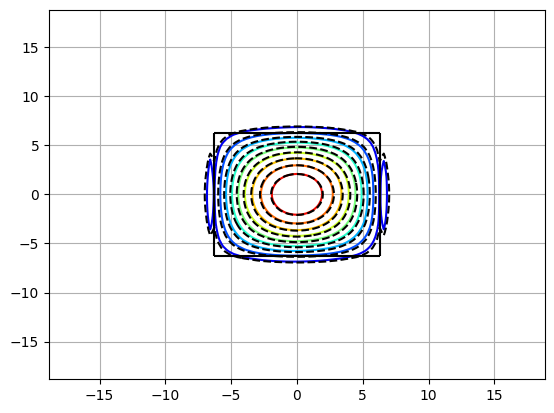

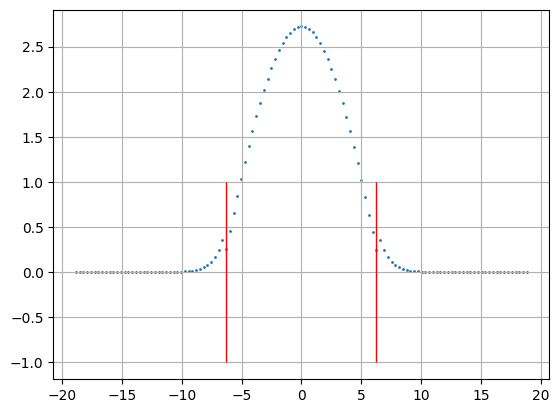

loss1 is  0.00261, loss2 is  0.00280, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00060, loss6 is  0.03307, total loss  0.03909, RI value  1.66979:  27%|██▋       | 2999/11001 [01:44<04:34, 29.16it/s]

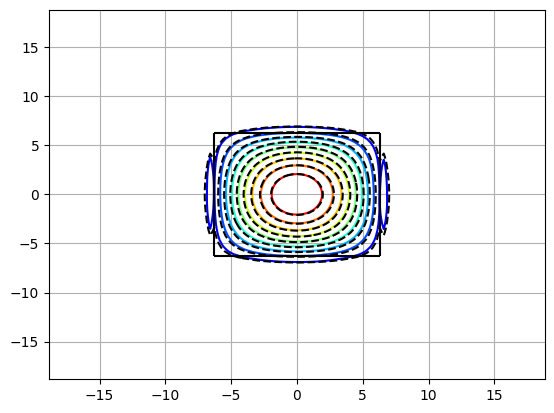

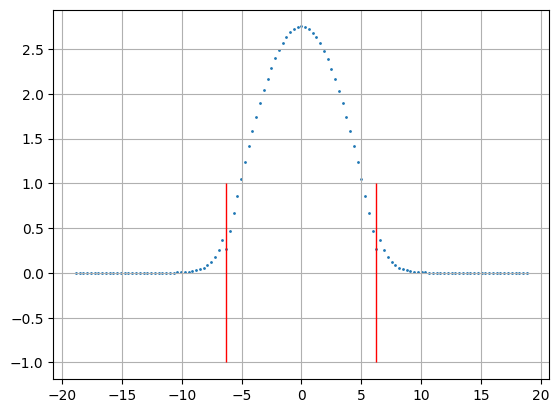

loss1 is  0.00260, loss2 is  0.00276, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00077, loss6 is  0.03241, total loss  0.03855, RI value  1.66979:  32%|███▏      | 3497/11001 [02:03<04:25, 28.25it/s]

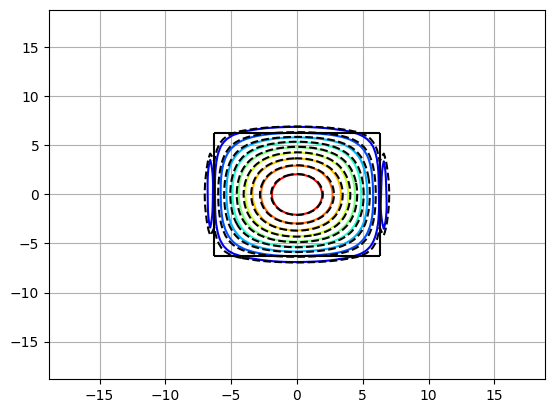

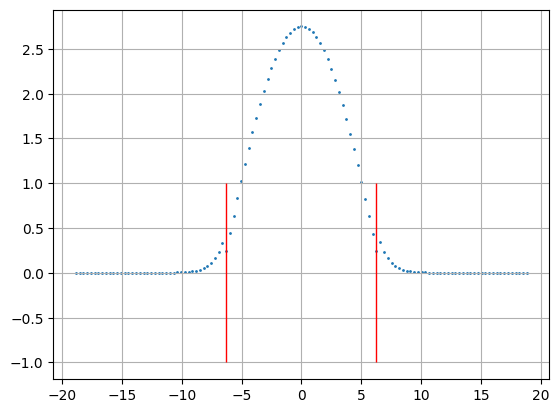

loss1 is  0.00255, loss2 is  0.00270, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00081, loss6 is  0.03456, total loss  0.04062, RI value  1.66981:  36%|███▋      | 3999/11001 [02:21<04:12, 27.69it/s]

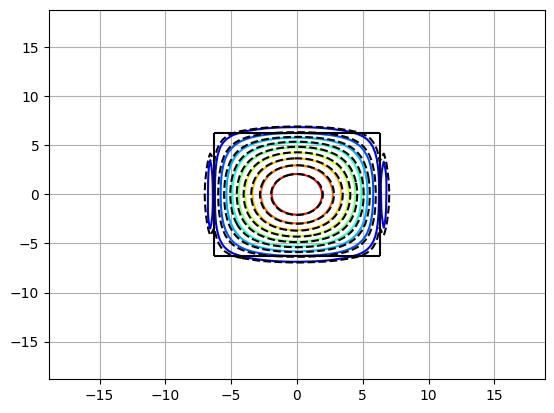

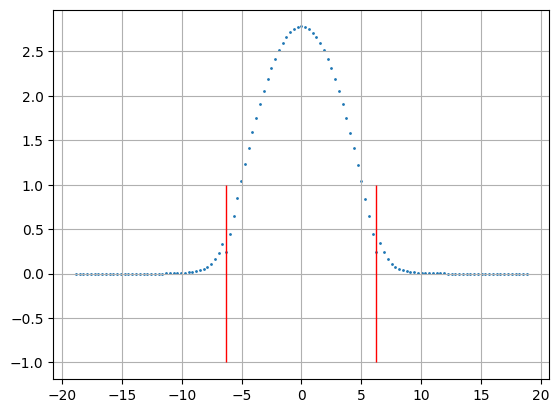

loss1 is  0.00240, loss2 is  0.00275, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00074, loss6 is  0.03135, total loss  0.03723, RI value  1.66973:  41%|████      | 4498/11001 [02:40<04:15, 25.48it/s]

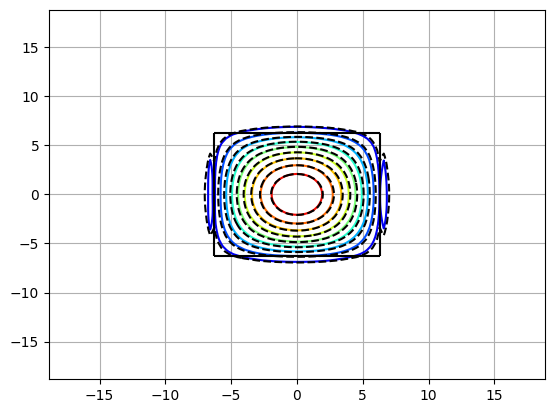

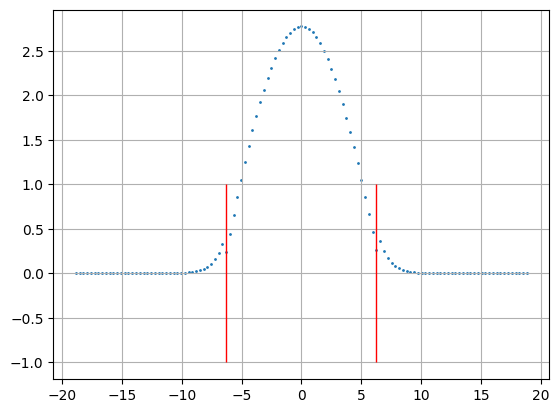

loss1 is  0.00266, loss2 is  0.00276, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00082, loss6 is  0.03251, total loss  0.03876, RI value  1.66987:  45%|████▌     | 4999/11001 [02:59<03:37, 27.55it/s]

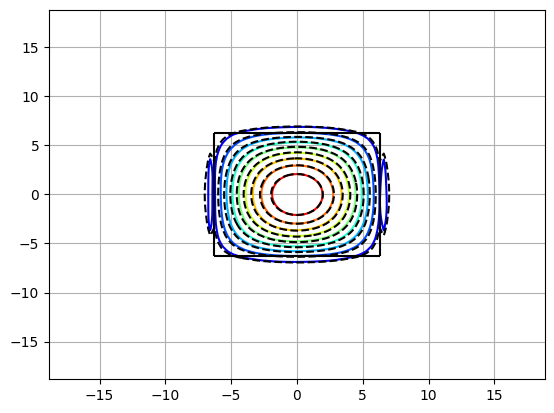

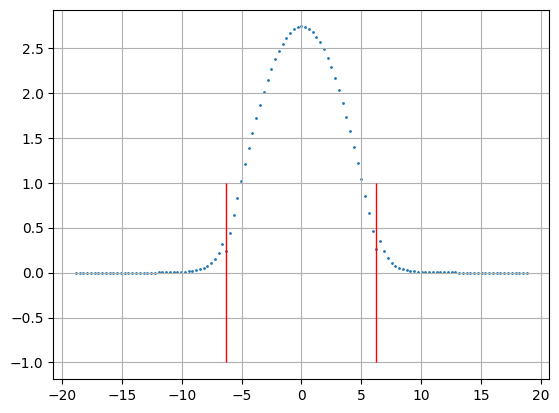

loss1 is  0.00253, loss2 is  0.00260, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00067, loss6 is  0.03168, total loss  0.03748, RI value  1.66983:  50%|████▉     | 5500/11001 [03:18<03:26, 26.66it/s]

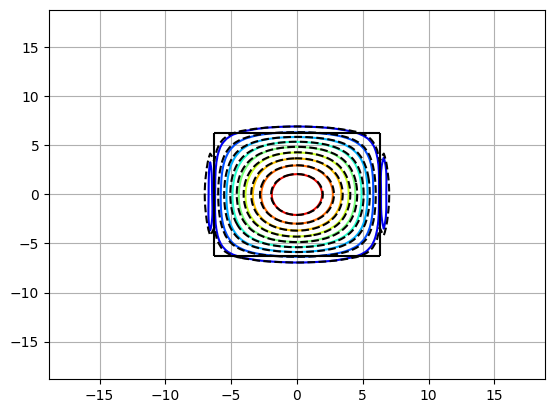

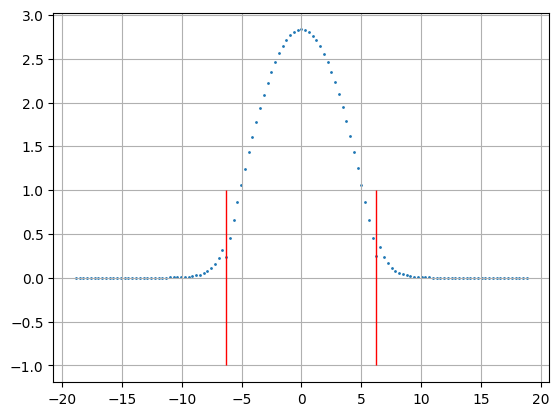

loss1 is  0.00247, loss2 is  0.00250, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00059, loss6 is  0.03595, total loss  0.04151, RI value  1.66981:  55%|█████▍    | 5999/11001 [03:37<02:59, 27.94it/s]

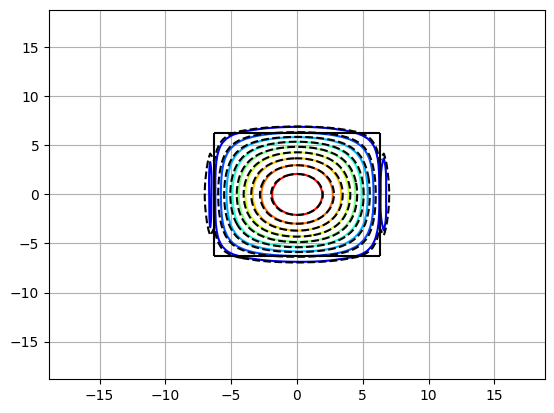

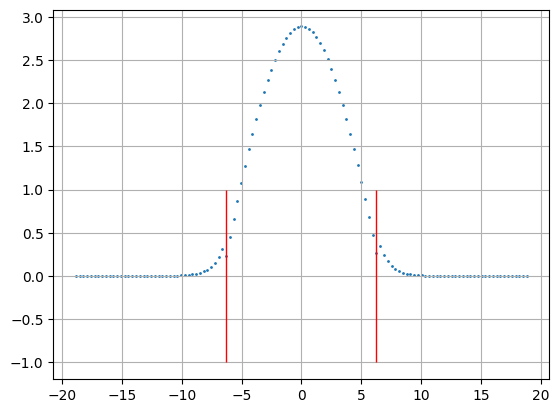

loss1 is  0.00264, loss2 is  0.00242, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00084, loss6 is  0.02808, total loss  0.03399, RI value  1.66949:  59%|█████▉    | 6498/11001 [03:56<02:41, 27.92it/s]

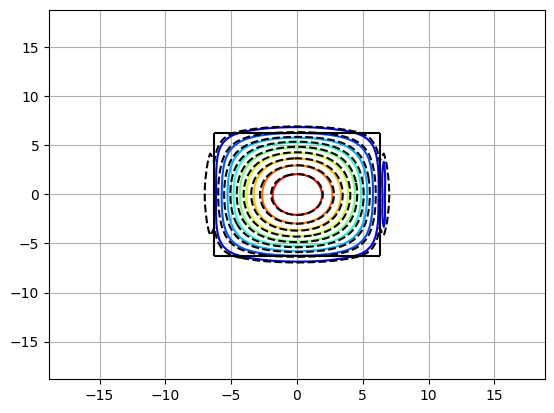

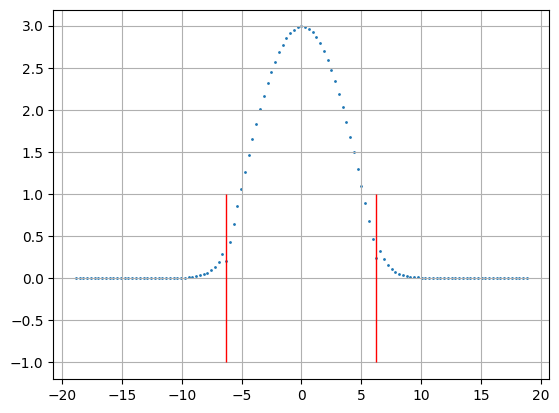

loss1 is  0.00226, loss2 is  0.00232, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00065, loss6 is  0.03143, total loss  0.03666, RI value  1.66951:  64%|██████▎   | 6999/11001 [04:15<02:16, 29.29it/s]

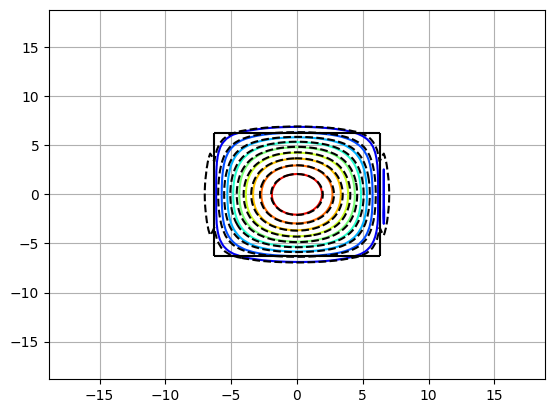

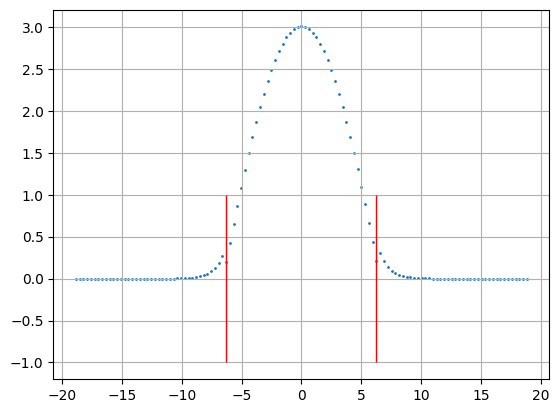

loss1 is  0.00218, loss2 is  0.00253, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00036, loss6 is  0.03412, total loss  0.03919, RI value  1.66924:  68%|██████▊   | 7500/11001 [04:34<02:16, 25.64it/s]

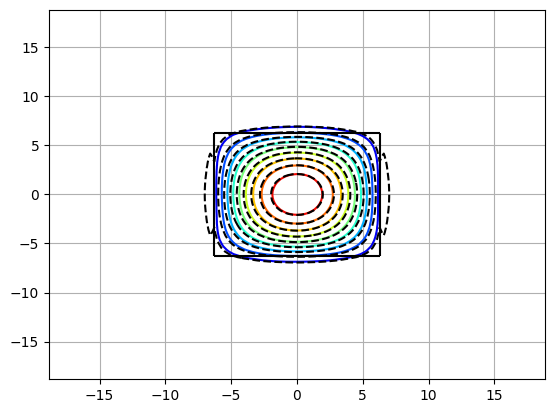

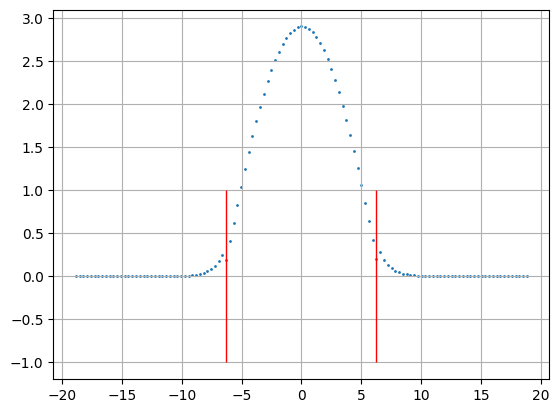

loss1 is  0.00264, loss2 is  0.00239, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00051, loss6 is  0.02526, total loss  0.03081, RI value  1.66929:  73%|███████▎  | 7998/11001 [04:53<01:44, 28.68it/s]

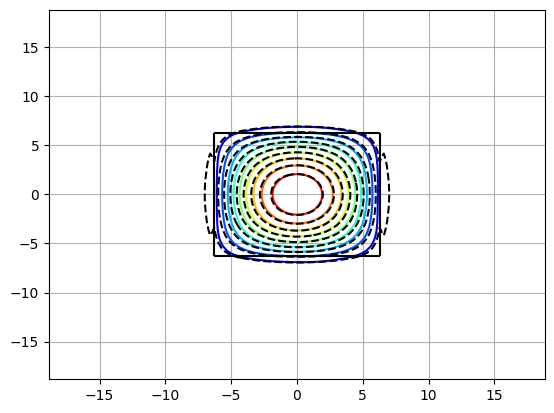

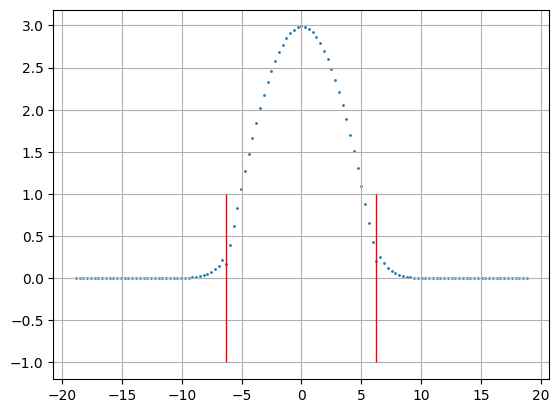

loss1 is  0.00281, loss2 is  0.00237, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00052, loss6 is  0.02529, total loss  0.03099, RI value  1.66901:  77%|███████▋  | 8500/11001 [05:10<01:18, 31.69it/s]

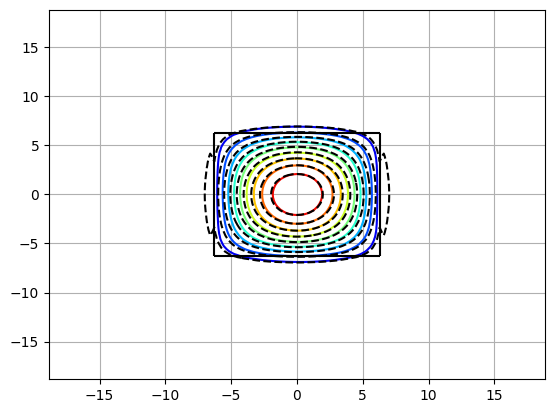

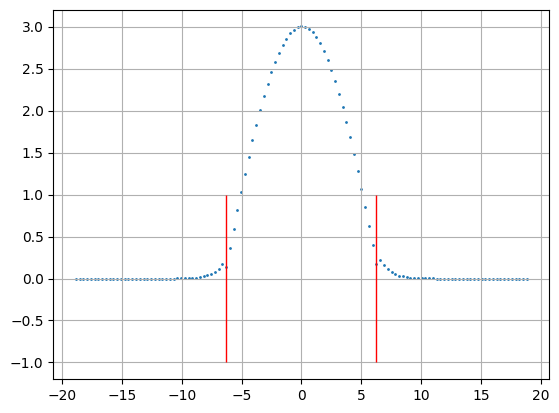

loss1 is  0.00246, loss2 is  0.00222, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00060, loss6 is  0.02357, total loss  0.02885, RI value  1.66850:  82%|████████▏ | 9000/11001 [05:27<01:07, 29.63it/s]

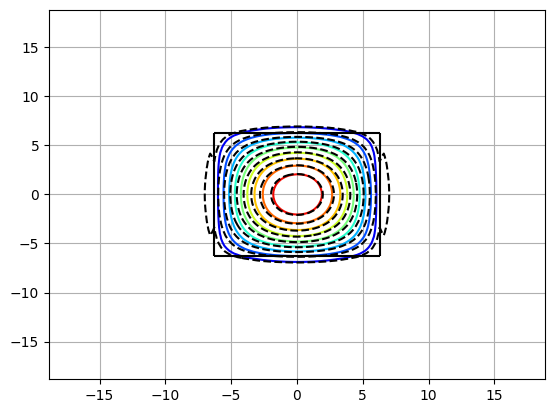

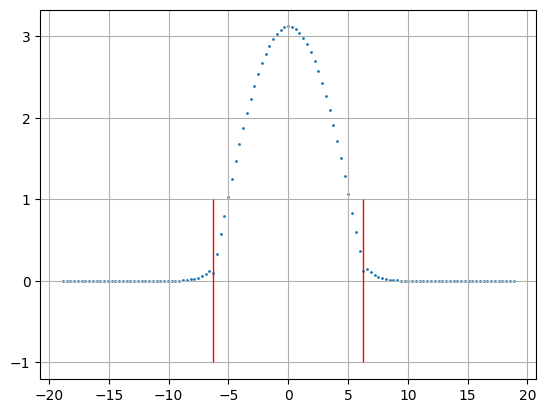

loss1 is  0.00257, loss2 is  0.00213, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00056, loss6 is  0.01665, total loss  0.02189, RI value  1.66806:  86%|████████▋ | 9498/11001 [05:45<00:47, 31.67it/s]

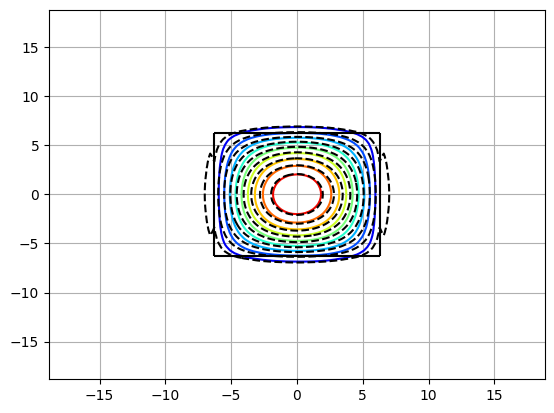

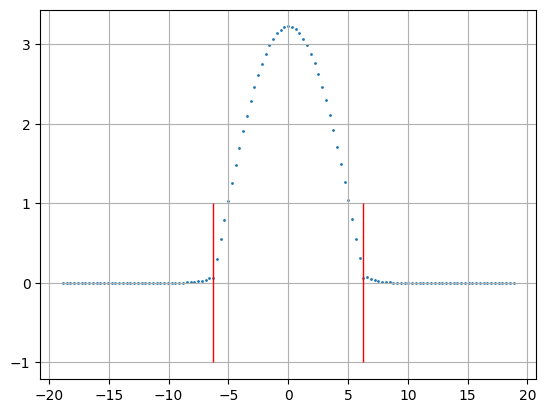

loss1 is  0.00452, loss2 is  0.00238, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00081, loss6 is  0.01607, total loss  0.02378, RI value  1.66780:  91%|█████████ | 9998/11001 [06:02<00:34, 28.89it/s]

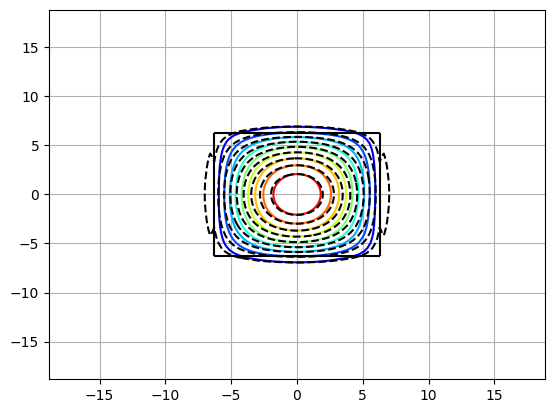

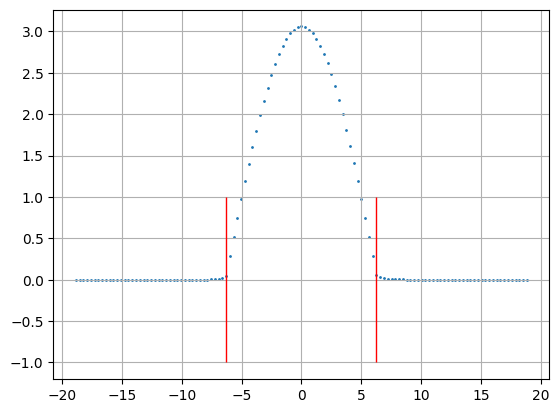

loss1 is  0.00295, loss2 is  0.00208, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00087, loss6 is  0.01163, total loss  0.01753, RI value  1.66759:  95%|█████████▌| 10499/11001 [06:20<00:16, 30.13it/s]

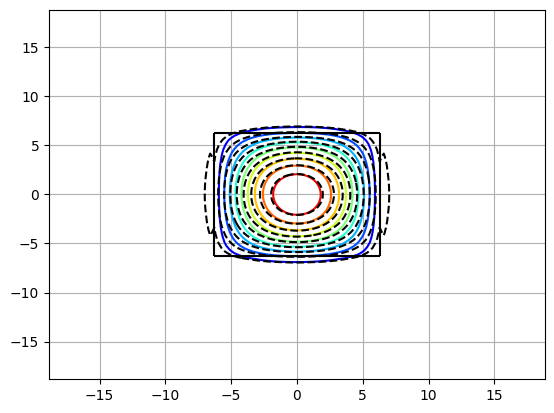

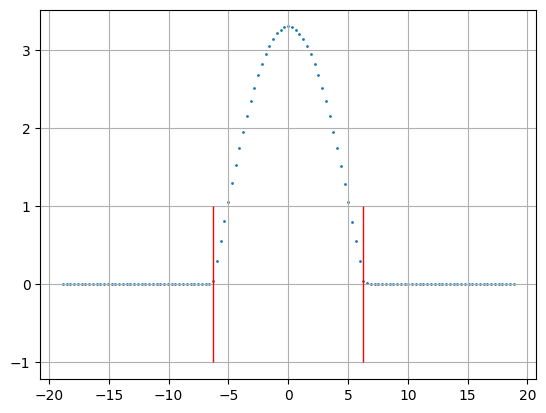

loss1 is  0.00351, loss2 is  0.00246, loss3 is  0.00000, loss4 is  0.00000, loss5 is  0.00047, loss6 is  0.02824, total loss  0.03467, RI value  1.66738:  97%|█████████▋| 10695/11001 [06:27<00:11, 27.61it/s]


KeyboardInterrupt: 

In [57]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(2001, num_modes, weights=weights, m=m, verbose=10, calc_error=False, plot_solution=True)

In [29]:
base_model.to('cpu');
base_model.to(torch.float64);

In [30]:
# yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
# end_val_yu = yu[-1]
# yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
# end_val_yb = yb[-1]
# xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))

# xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
# # if device.augmented_input:
# #   xy = torch.cat((xy, (1/reference_device.regions(xy, format='torch').view(-1, 1))), dim=-1)
# u = base_model.forward_with_features(xy.cpu()).cpu()

In [31]:
# plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
# plt.grid()

In [32]:
xy = torch.arange(0, device.total_length_x/2, dx, dtype=torch.float64).reshape(-1, 1)
xy = torch.cat((-torch.flip(xy, dims=(0,))[:-1], xy))

xy = torch.cat((xy, torch.full_like(xy, 0*dx)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, (reference_device.make_features(xy).view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()

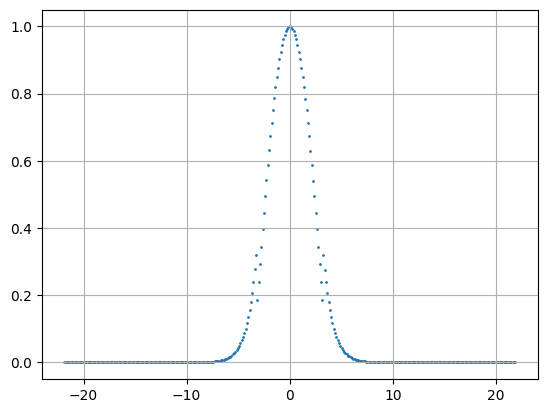

In [33]:
plt.scatter(xy[:, 0].cpu().detach(), u, s=1)
plt.grid()

In [34]:
len(xy[:])

349

In [35]:
# plt.stem(xy[50:65, 0].detach().numpy(), u[50:65, 0].detach().numpy())
# plt.show()
# plt.stem(xy[95-1:110, 0].detach().numpy(), u[75-1:90, 0].detach().numpy())
# plt.show()

In [36]:
reference_device_fd = devices.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy)

In [37]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float64)

In [38]:
print(np.sqrt(RI_squared))

[1.59858063]


In [39]:
xy = torch.cat((xy_fd, device.make_features(xy_fd)), dim=-1)
xy.requires_grad = True
NN_EI = [device.calculate_eigen_value(xy, 0).item()**(1/2)]
print(NN_EI)
base_model.to('cpu');
xy = xy.detach()

[1.5949933504456832]


In [40]:
Nx = device.total_length_x // dx
Ny =  device.total_length_y // dy

len(xy), Nx*Ny

(121801, 122500.0)

140
tensor([], dtype=torch.float64)


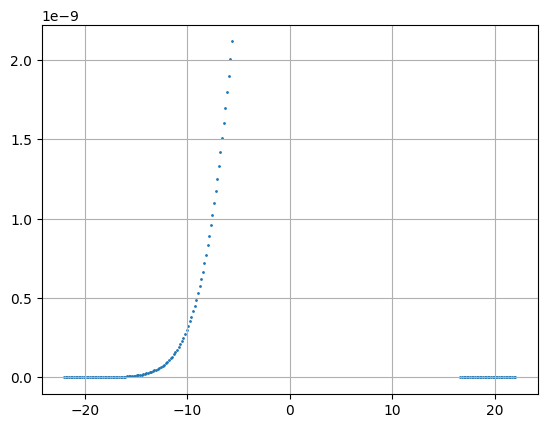

In [75]:
i = int(Ny/2)
row_length = int(Nx)
print(row_length)
print(xy_fd[len(u_fd) * i:len(u_fd) * (i + 1), 0])
plt.scatter(xy_fd[row_length * i: row_length * (i + 1), 0], u_fd[row_length * i:row_length * (i + 1), 0], s=1)
plt.grid()

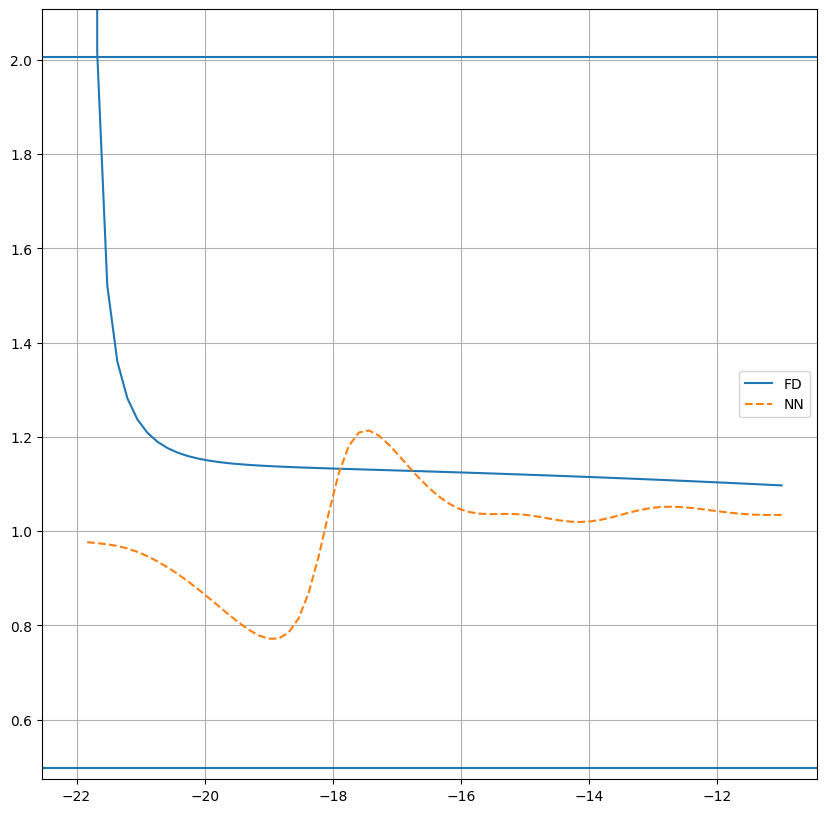

In [76]:
ratio_fd = u_fd[row_length * i:row_length * (i + 1), 0]/u_fd[row_length * i - 1: row_length * (i + 1)-1, 0]
half_index = len(ratio_fd)//2
quarter_index = len(ratio_fd)//4
xy_fd_slice = xy_fd[row_length * i:row_length * (i + 1)][half_index-quarter_index:half_index+quarter_index+1]

u = train_agent.evaluate(xy_fd_slice.cpu())[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()
ratio_nn = u[1:]/u[0:-1]

plt.figure(figsize=(10, 10))
plt.plot(xy_fd_slice[:, 0], ratio_fd[half_index-quarter_index:half_index+quarter_index+1], label='FD')

# plt.stem(xy[50:65, 0].detach().numpy(), -u[50:65, 0].detach().numpy())
# plt.show()
# plt.stem(xy[75-1:90, 0].detach().numpy(), -u[75-1:90, 0].detach().numpy())
# plt.show()
plt.plot(xy_fd_slice[1:, 0], ratio_nn, linestyle='--', label='NN')
plt.axhline(y=(n_core**2)/(n_substrate**2))
plt.axhline(y=(n_substrate**2)/(n_core**2))
plt.ylim([(n_substrate**2)/(n_core**2)*0.95, (n_core**2)/(n_substrate**2)*1.05])
plt.grid()
plt.legend()

In [84]:
u = base_model(xy.cpu())
u = u/torch.max(torch.abs(u))
u_fd = u_fd/np.max(np.abs(u_fd))

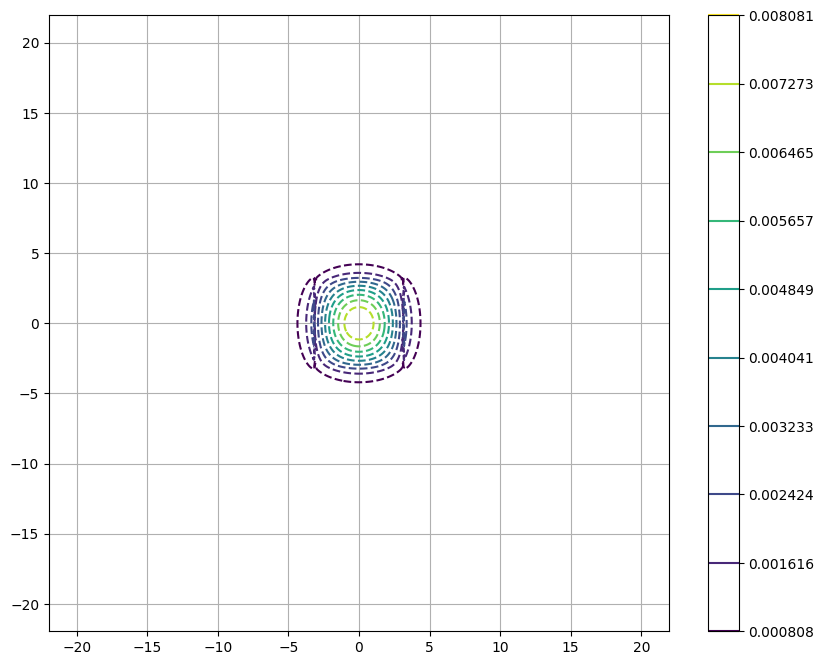

In [290]:
levels = np.linspace(0, np.max(np.abs(u_fd)), 11)[1:]
plt.figure(figsize=(10, 8))
# plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), -u[:,0].detach(), cmap='jet', levels=levels)
plt.tricontour(xy_fd[::4, 0], xy_fd[::4, 1], -u_fd[::4,0], linestyles='dashed', levels=levels)
plt.colorbar()
plt.grid()

In [ ]:
save_folder_path = r"C:\Users\asmaa\Desktop\Amr\2nd Paper\Experiments"

In [ ]:
# np.save(save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\DCNN_field.npy', u.detach().numpy())
# torch.save(base_model.state_dict(), save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\DCNN.pty')
# np.save(save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\NN_EI.npy', NN_EI)
 
# np.save(save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\FD_field.npy', u_fd)
# np.save(save_folder_path + r'\NonPlanar\Single Mode Moderate Contrast\FD_EI.npy', [RI_squared])